# Geolocation Integration

This notebook converts IP addresses to integer format, merges `Fraud_Data.csv` with `IpAddress_to_Country.csv` using range-based lookup, and analyzes fraud patterns by country.

In [1]:
import sys
from pathlib import Path

proj_root = Path.cwd().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from src.data_processing import (
    load_fraud_data, load_ip_to_country, handle_cleaning,
    prepare_ip_ranges, add_ip_country, add_country_risk_features,
    get_fraud_by_country, get_country_distribution,
    get_fraud_prob_by_country_count, get_fraud_prob_by_ip_sharing,
)

sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

## 1. Load Data

In [2]:
df = load_fraud_data()
print(f"Fraud_Data shape: {df.shape}")
df.head()

Fraud_Data shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
ip_df = load_ip_to_country()
print(f"IpAddress_to_Country shape: {ip_df.shape}")
ip_df.head()

IpAddress_to_Country shape: (138846, 3)


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


## 2. Convert IP Addresses to Integer Format

In [4]:
df["ip_address_int"] = df["ip_address"].astype(int)
print("IP addresses converted to integer format.")
df[["ip_address", "ip_address_int"]].head()

IP addresses converted to integer format.


,ip_address,ip_address_int
0,7.327584e+08,732758368
1,3.503114e+08,350311387
2,2.621474e+09,2621473820
3,3.840542e+09,3840542443
4,4.155831e+08,415583117


## 3. Merge with IpAddress_to_Country.csv (Range-Based Lookup)

In [5]:
ip_ranges = prepare_ip_ranges(ip_df)
df = add_ip_country(df, ip_ranges)
print(f"Unique countries mapped: {df['country'].nunique()}")
df[["ip_address_int", "country"]].head(10)

Unique countries mapped: 182


,ip_address_int,country
0,732758368,Japan
1,350311387,United States
2,2621473820,United States
3,3840542443,Unknown
4,415583117,United States
5,2809315199,Canada
6,3987484328,Unknown
7,1692458727,United States
8,3719094257,China
9,341674739,United States


## 4. Country Distribution

In [6]:
country_dist = get_country_distribution(df)
print(f"Total countries: {len(country_dist)}")
print("\nTop 15 countries by transaction count:")
print(country_dist.head(15))

Total countries: 182

Top 15 countries by transaction count:
               country  count
0        United States  58049
1              Unknown  21966
2                China  12038
3                Japan   7306
4       United Kingdom   4490
5    Korea Republic of   4162
6              Germany   3646
7               France   3161
8               Canada   2975
9               Brazil   2961
10               Italy   1944
11           Australia   1844
12         Netherlands   1680
13  Russian Federation   1616
14               India   1310


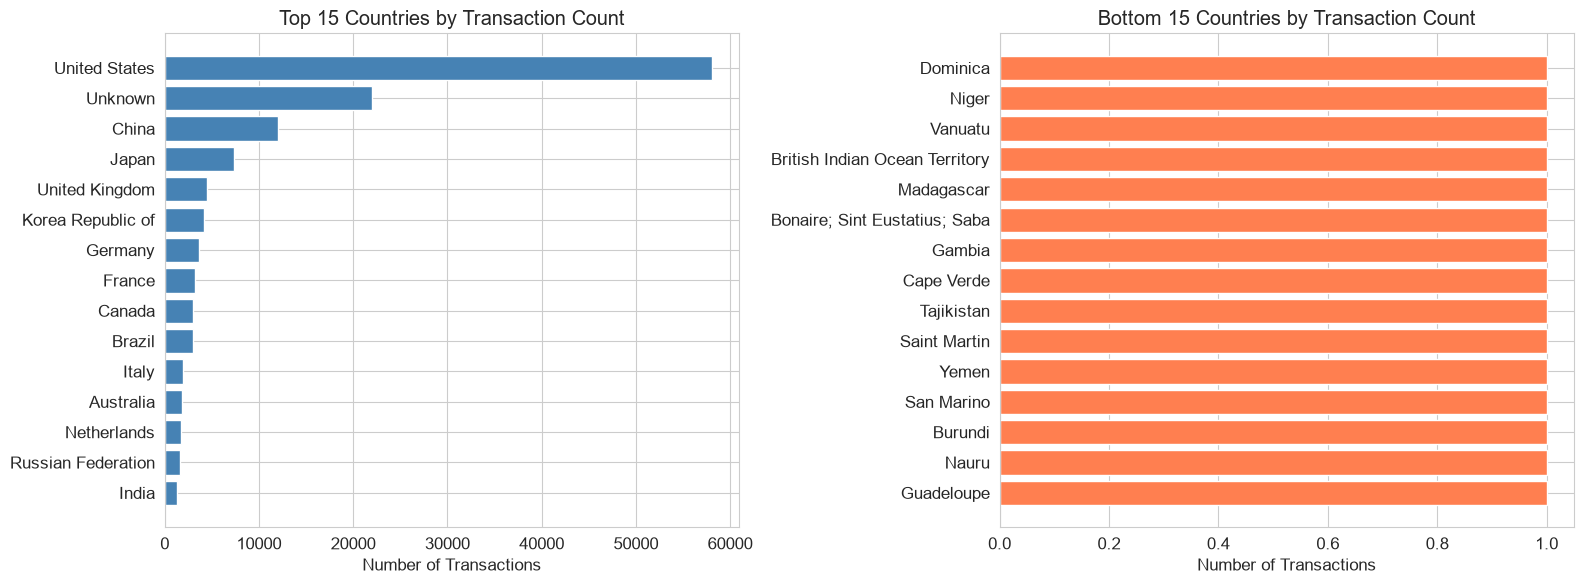

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_15 = country_dist.head(15)
axes[0].barh(top_15["country"], top_15["count"], color="steelblue")
axes[0].set_xlabel("Number of Transactions")
axes[0].set_title("Top 15 Countries by Transaction Count")
axes[0].invert_yaxis()

bottom_15 = country_dist.tail(15)
axes[1].barh(bottom_15["country"], bottom_15["count"], color="coral")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_title("Bottom 15 Countries by Transaction Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Fraud Patterns by Country

In [8]:
fraud_by_country = get_fraud_by_country(df, min_transactions=100)
print("Fraud rate by country (min 100 transactions):")
fraud_by_country.head(20)

Fraud rate by country (min 100 transactions):


,fraud_rate,total_transactions
country,,
Ecuador,26.415094,106
Tunisia,26.271186,118
Peru,26.050420,119
Ireland,22.916667,240
New Zealand,22.302158,278
Saudi Arabia,18.939394,264
Denmark,15.918367,490
Chile,15.347722,417
Greece,14.285714,231


In [9]:
df_country_risk, significant_countries = add_country_risk_features(df)
print(f"High-risk countries: {df_country_risk['is_high_risk_country'].sum()} transactions")
print(f"Unknown country transactions: {df_country_risk['is_unknown_country'].sum()}")
significant_countries.head(10)

High-risk countries: 2377 transactions
Unknown country transactions: 21966


,fraud_rate,total_transactions
country,,
Algeria,0.106557,122
Argentina,0.099849,661
Australia,0.089479,1844
Austria,0.075862,435
Belgium,0.136919,409
Brazil,0.091185,2961
Bulgaria,0.012048,166
Canada,0.116975,2975
Chile,0.153477,417


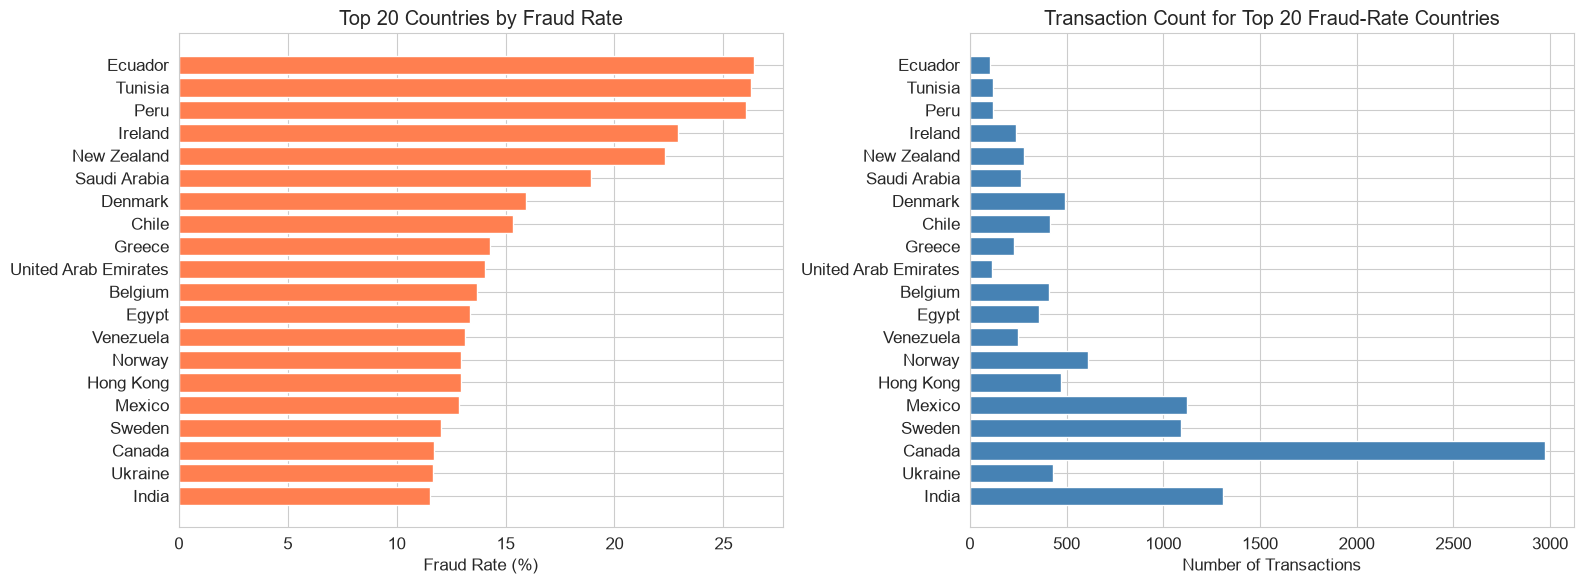

In [10]:
top_20_fraud = fraud_by_country.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_20_fraud.index, top_20_fraud["fraud_rate"], color="coral")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].set_title("Top 20 Countries by Fraud Rate")
axes[0].invert_yaxis()

axes[1].barh(top_20_fraud.index, top_20_fraud["total_transactions"], color="steelblue")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_title("Transaction Count for Top 20 Fraud-Rate Countries")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Fraud Probability by Country Transaction Count

In [11]:
country_count_stats = get_fraud_prob_by_country_count(df, min_transactions=50)
print("Fraud probability by country transaction count:")
country_count_stats.head(15)

Fraud probability by country transaction count:


,fraud_rate,total_transactions
country,,
United States,9.562611,58049
Unknown,8.572339,21966
China,8.664230,12038
Japan,9.786477,7306
United Kingdom,10.623608,4490
Korea Republic of,9.130226,4162
Germany,7.185957,3646
France,9.490668,3161
Canada,11.697479,2975


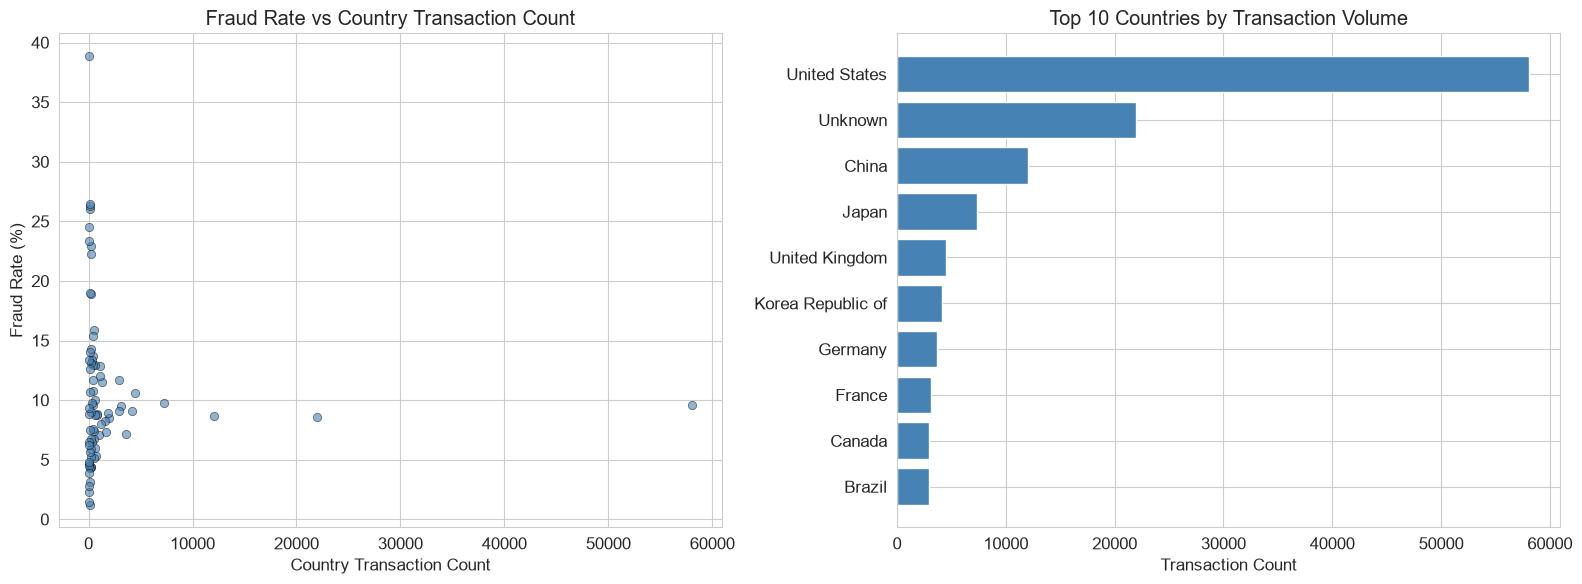

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(country_count_stats["total_transactions"], 
                country_count_stats["fraud_rate"], 
                alpha=0.6, color="steelblue", edgecolors="black", linewidths=0.5)
axes[0].set_xlabel("Country Transaction Count")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_title("Fraud Rate vs Country Transaction Count")

top_10_by_txn = country_count_stats.nlargest(10, "total_transactions")
axes[1].barh(top_10_by_txn.index, top_10_by_txn["total_transactions"], color="steelblue")
axes[1].set_xlabel("Transaction Count")
axes[1].set_title("Top 10 Countries by Transaction Volume")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Fraud Probability by IP Address Sharing Count

In [13]:
ip_sharing_stats = get_fraud_prob_by_ip_sharing(df)
print("Fraud probability by IP sharing count:")
ip_sharing_stats

Fraud probability by IP sharing count:


,avg_fraud_rate,num_ips
ip_sharing_count,,
1,4.565260,142752
2,50.000000,1
3,66.666667,2
4,81.250000,4
5,80.000000,13
6,83.888889,30
7,86.571429,50
8,87.852113,71
9,89.701897,82


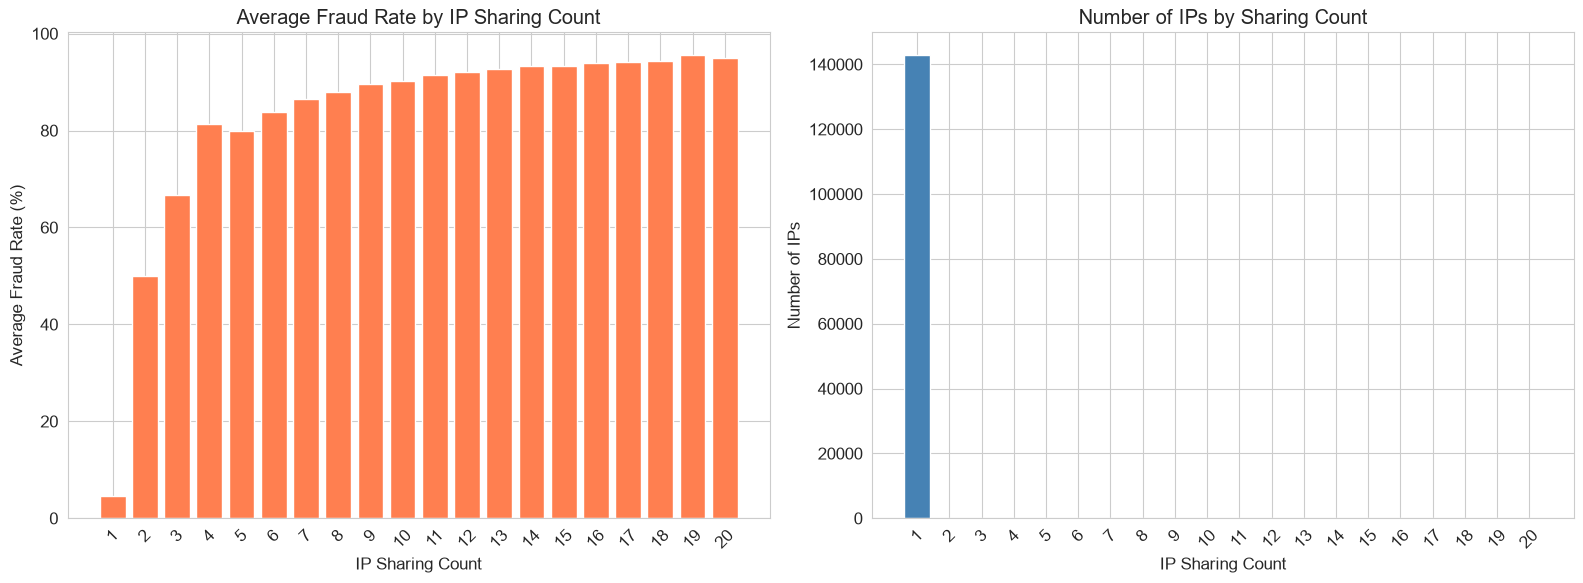

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(ip_sharing_stats.index.astype(str), ip_sharing_stats["avg_fraud_rate"], color="coral")
axes[0].set_xlabel("IP Sharing Count")
axes[0].set_ylabel("Average Fraud Rate (%)")
axes[0].set_title("Average Fraud Rate by IP Sharing Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(ip_sharing_stats.index.astype(str), ip_sharing_stats["num_ips"], color="steelblue")
axes[1].set_xlabel("IP Sharing Count")
axes[1].set_ylabel("Number of IPs")
axes[1].set_title("Number of IPs by Sharing Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 8. Summary

In [15]:
print("Geolocation Analysis Summary:")
print(f"  Total transactions: {len(df):,}")
print(f"  Unique countries: {df['country'].nunique()}")
print(f"  High-risk country transactions: {df_country_risk['is_high_risk_country'].sum():,}")
print(f"  Unknown country transactions: {df_country_risk['is_unknown_country'].sum():,}")
print(f"  Overall fraud rate: {df['class'].mean()*100:.2f}%")

Geolocation Analysis Summary:
  Total transactions: 151,112
  Unique countries: 182
  High-risk country transactions: 2,377
  Unknown country transactions: 21,966
  Overall fraud rate: 9.36%
